# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Gonzaga, Thomas
- _Student No._: 2023-16222
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

![Description](Line.png)

### Report discussion

The basis used for the linear equations used for this problem was based on the Ohm's Law and Kirchoff's Law. Drawing out the values for nodes at the start, begginning, and end of the chain shows us a pattern that can be generalized into matrix and vector equations.

After setting up the matrices I was able to solve the matrix equations by simply using the `np.linalg.solve` function of NumPy which basically solves the linear matrix equation which includes systems of linear equations. Opening the source code for `np.linalg.solve` presesnts us with a very very very long piece of code.

For the case where N = 10,000 we could not simply just use `np.linalg.solve` to free us of our troubles, we had to rely on Mark Newman's `banded.py` code. This code basically cuts down the useless 0 values that make up most of the very large matrix (a 10,000 by 10,000 matrix would have like 100 million entries. Mark Newman's code cuts this down by 'ignoring' the 0 values and only focusing on the parts of the matrix we actually care about.

![Description](Histogram.png)

Tried using a histogram but not sure if this is good. All this shows is that the values are more evenly spread across all the nodes of the system, although you can already see that in the first figure.

### Other comments
- for matrices with repeating patterns, using Aa[0,:] something soething might be useful
- I don't really know what a histogram would show but ig probability?


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [1]:
import numpy as np
import banded as bd
import matplotlib.pyplot as plt

In [2]:
# defining A for N=6
A = np.array ([
    [3, -1, -1, 0, 0, 0],
    [-1, 4, -1, -1, 0, 0],
    [-1, -1, 4, -1, -1, 0],
    [0, -1, -1, 4, -1, -1],
    [0, 0, -1, -1, 4, -1],
    [0, 0, 0, -1, -1, 3]
])

# defining w for N=6
w = np.array ([
    [5],
    [5],
    [0],
    [0],
    [0],
    [0],
])

V = np.linalg.solve(A, w)

print(V)

[[3.7254902 ]
 [3.43137255]
 [2.74509804]
 [2.25490196]
 [1.56862745]
 [1.2745098 ]]


In [3]:
# checking
print(A)
print(w)

[[ 3 -1 -1  0  0  0]
 [-1  4 -1 -1  0  0]
 [-1 -1  4 -1 -1  0]
 [ 0 -1 -1  4 -1 -1]
 [ 0  0 -1 -1  4 -1]
 [ 0  0  0 -1 -1  3]]
[[5]
 [5]
 [0]
 [0]
 [0]
 [0]]


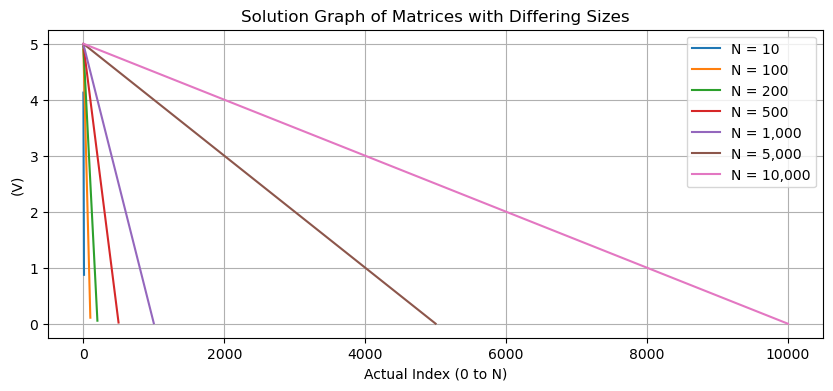

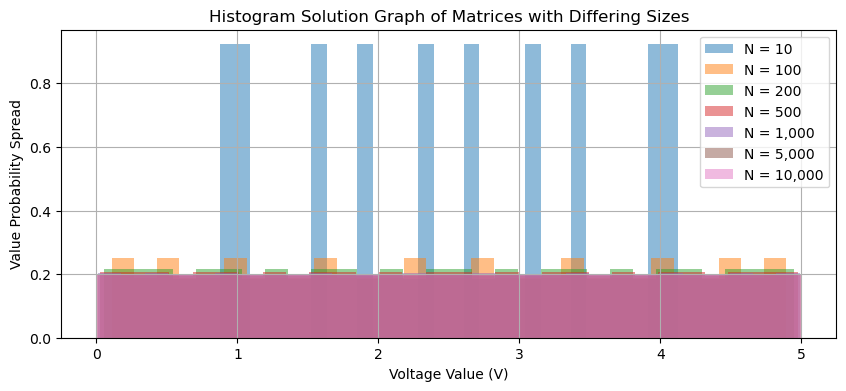

In [6]:
# Now we need to make a version that can accomodate N = 10,000
# for this case we have so many values that are just 0 (banded, ig like a band running diagonally in the matrix
# 10,000 x 10,000 is like 100 million entries my computer might explode
# we only need 5 entries in a single line (-1, -1, 4, -1, -1) max

# setting size
n_values = [10, 100, 200, 500, 1000, 5000, 10000]

# output holder
v_outputs = {}

# setting how many entries per line (up+1+down = 5)
up = 2
down = 2

for N in n_values:

    # making base matrix with 10000 row entries (just 0s)
    Aa = np.zeros((1 + up + down, N), dtype=float)
    
    # defining our 5 entries
    
    # outer-most upper diagonal possible values
    Aa[0, :] = -1.0   # upper diagonal 2 (outside -1 guys)
    Aa[0, 0] = 0.0    # ignored elements
    Aa[0, 1] = 0.0
    
    # outer-inside upper diagonal possible values
    Aa[1, :] = -1.0   # upper diagonal 1 (inside -1 guys)
    Aa[1, 0] = 0.0    # ignored element
    
    # middle/main
    Aa[2, :] = 4.0    # all diagonal entries are 4 except first and last
    Aa[2, 0] = 3.0    # first element is 3, 0 is 1
    Aa[2, -1] = 3.0   # last element is 3, -1 is last element
    
    # out-inside bottom diagonal possible values
    Aa[3, :] = -1.0   # lower diagonal 1 (-1 guys)
    Aa[3, -1] = 0.0   # ignored elements
    
    # out-inside bottom diagonal possible values
    Aa[4, :] = -1.0   # lower diagonal 2 (outdside -1 guys)
    Aa[4, -1] = 0.0   # 0gnored elements
    Aa[4, -2] = 0.0
    
    # first two rows have +5V and 9,998 zeros
    va = np.zeros(N, dtype=float)
    va[0] = 5.0
    va[1] = 5.0

    # named to match our banded import
    v_outputs[N] = bd.banded(Aa, va, up, down)


# plotting
plt.figure(figsize=(10, 4))

# extract each n and its v
for N, V_array in v_outputs.items():
    # scaling
    x_coords = np.arange(len(V_array))
    
    # plotting line
    plt.plot(x_coords, V_array, label=f"N = {N:,}")

plt.xlabel('Actual Index (0 to N)')
plt.ylabel('(V)')
plt.title('Solution Graph of Matrices with Differing Sizes')
plt.legend()
plt.grid(True)
plt.savefig('Line.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10,4))

for N, V_array in v_outputs.items():
    plt.hist(
        V_array,
        # how many spaces that the bars can fill ig, more = thinner bars (more accurate im assuming)
        bins=30,
        # density normalizes it so that the total value equates to 1 or 100% rather than just rawdogging the raw results
        density=True,
        # transparency so you can see stuff behind
        alpha=0.5, 
        label=f"N = {N:,}"
    )

plt.xlabel('Voltage Value (V)')
plt.ylabel('Value Probability Spread')
plt.title('Histogram Solution Graph of Matrices with Differing Sizes')
plt.legend()
plt.grid(True)
plt.savefig('Histogram.png', dpi=150)
plt.show()
plt.close()

#### Problem 1 code summary

The first code for part 1 and 2 are hardcoded for the specific N = 6 value. We first defined the A matrix after solving for it manually on paper and the $\omega$ vector that come out of it when solving $A*v$. For part 4 we needed to modify the code to accomodate for very large matrix sizes, so we instead used a different method of matrix building as larger matrices are banded. The code is written in a way where it can take in a list of N values and plot them all against each other in a line graph and histogram.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [5]:
import samplePackage as sP

ModuleNotFoundError: No module named 'samplePackage'

In [ ]:
sP.createZerosArray(4,5)